# DAI Mission — Proposal
**Data & AI in Economics | TU Dortmund**



## 1. Team

| Role | Name | 
|------|------|
| Lead | Mariia Hrechyn| 
| Member | Lutz Weiland | 


## 2. Mission Title & Research Question

**Title:** *From Balance Sheets to Buy Signals: Causal, Supervised, and Unsupervised Analysis of Fundamental Stock Return Prediction*

**Research question:**  
*Can fundamental financial ratios derived from income statements, balance sheets, and cash-flow statements reliably predict 1-year stock return direction (buy / hold / sell) for US-listed firms? 
Specifically: 

- (i) which latent fundamental profiles (clusters) carry the most predictive information, 
- (ii) does profitability (ROE) causally drive future return class after controlling for sector and leverage, and 
- (iii) do ensemble classifiers outperform a Fama-French 3-factor economic baseline because they learn stronger class-specific signals from accounting variables, or because they better resolve uncertainty in the ambiguous hold class?*

**Why it matters:**  
*Fundamental analysis is central to active investment management, yet it is rarely subjected to rigorous causal scrutiny — most ML studies on financial data report predictive correlations without separating genuine economic drivers from sector-level confounders. This project applies three complementary lenses to a self-constructed dataset of US public-company fundamentals (SimFin, CC BY-NC 4.0): unsupervised clustering to discover latent firm archetypes, causal inference to distinguish structural profitability drivers from correlates, and supervised classification benchmarked against the Fama-French factor model. Requiring all three lenses to inform each other tests whether data-driven fundamental analysis adds genuine economic value beyond established factor heuristics, or merely re-packages known market risks in a more complex form.*

## 3. Data

**Primary Source:** SimFin — Fundamental Financial Data for US-listed Companies  
Provider: SimFin ApS (Denmark)  
Access: https://simfin.com/data/access/api (free tier, Python package `simfin`)  
Licence: **CC BY-NC 4.0** — free for academic use with attribution.

---

### 3a. Raw Dataset Retrieved (`simfin_data_retrieval.ipynb`)

The data retrieval script (`simfin_data_retrieval.ipynb`) fetches all available annual US fundamentals from the SimFin API and merges them into a single panel. The raw panel saved as `simfin_raw_panel.csv` has the following characteristics:

| Property | Value |
|----------:|-------|
| Rows (company × fiscal-year) | **18,088** |
| Columns (raw features + metadata) | **86** |
| Unique tickers | **4,787** |
| Fiscal years covered | **2020 – 2024** |
| Currency filter | USD only |
| Statement types merged | Income statement (standard / bank / insurance), Balance sheet, Cash-flow statement |

The retrieval script loads three statement types for each of three firm categories (standard, bank, insurance), outer-joins them on Ticker × Report Date, attaches company/sector metadata from SimFin's reference tables, filters to USD-denominated firms, and saves the raw panel before any cleaning. The overall missing rate in the raw panel is **~40%**, driven primarily by bank- and insurance-specific columns that are structurally absent for standard firms.

---

### 3b. Target Variable Construction

The target variable is constructed in two steps:

**Step 1 — 1-year forward total return (`Perform`)**  
For each company × fiscal-year observation, we look up the adjusted closing price on the report date and again 252 trading days later. The continuous return is:

```
Perform = (Price_{t+252} − Price_{t}) / Price_{t}
```

Observations where either price is unavailable (no price data within a 5-day tolerance window) are left as `NaN` and excluded from modelling. This yields **13,601 non-null return observations** out of 18,088 total.

**Step 2 — Ternary class label (`Class`)**  
Within each fiscal year, firms are ranked by `Perform` and divided into three equal terciles:

| Class | Label | Meaning |
|------:|-------|---------|
| **−1** | Sell | Bottom third of annual returns (within fiscal year) |
| **0** | Hold | Middle third |
| **+1** | Buy | Top third |

Tercile assignment is performed within-year (not globally) so that class balance is guaranteed by construction (~33% per class, ~4,534 observations each). This removes the effect of overall market direction — a buy signal means outperforming two-thirds of peers in the same fiscal year, not simply a positive return.

---

### 3c. Pre-processing Plan (`data_preprocessing.ipynb`)

Before modelling, the raw panel undergoes the following pre-processing steps (implemented in `data_preprocessing.ipynb`):

1. **Missing value inspection** — Compute per-column missing rates across all 86 raw columns. Visualise as a sorted bar chart and missingness heatmap to identify structural vs. incidental gaps.

2. **Column dropping** — Columns with more than 50% missing values (30 columns, including bank- and insurance-specific items with >95% absence) are dropped. This reduces the feature set from 86 to 61 columns.

3. **Sector-median imputation** — Remaining missing values in the 46 numeric feature columns are filled with the sector-level median for that column. For rows without a sector label (or sectors where the entire column is NaN), the global column median is used as a fallback. After imputation, 0 missing cells remain in the feature set.

4. **Winsorisation** — Derived financial ratios (ROE, ROA, Leverage, GrossMargin, OperatingMargin, CurrentRatio, DebtRatio, CFO_Margin) are clipped to the 1st–99th percentile to suppress extreme outliers from near-zero denominators (e.g., near-zero equity inflating ROE).

5. **Z-score standardisation** — Ratio features are standardised (zero mean, unit variance) before PCA and clustering to prevent high-magnitude variables from dominating distance calculations. Raw statement line items are scaled separately for the supervised block.

---

**Final modelling dataset:** `simfin_cleaned_imputed.csv`  
Shape: **13,601 observations × 61 columns** (rows with missing `Class` or `Perform` excluded)  
Unique tickers: **4,309** | Fiscal years: **2020–2024**

**Unit of observation:** One row = one company × fiscal year snapshot.  
Each row contains raw statement line items plus 8 derived financial ratios and a ternary class label.

---

**Income Statement columns** (`fin_type`)

| Column | Type | Role |
|--------|------|------|
| `Revenue` | Continuous | Feature / ratio denominator — top-line sales; scale anchor for all margin ratios |
| `Cost of Revenue` | Continuous | Feature — direct production costs; high values compress gross margin and signal low pricing power |
| `Gross Profit` | Continuous | Feature / GrossMargin numerator — revenue minus direct costs; measures the core operating surplus before overhead |
| `Operating Expenses` | Continuous | Feature — overhead burden (SG&A + R&D); high relative to revenue flags operational inefficiency |
| `Selling, General & Administrative` | Continuous | Feature — overhead spending on sales and administration; inflated values can signal poor cost control |
| `Operating Income (Loss)` | Continuous | Feature / OperatingMargin numerator — profit from core operations before interest and taxes; key measure of business quality |
| `Non-Operating Income (Loss)` | Continuous | Feature — one-off gains/losses (asset sales, FX); noisy signal, can distort comparisons across firms |
| `Interest Expense, Net` | Continuous | Feature — cost of debt financing; higher values indicate greater leverage burden and financial risk |
| `Pretax Income (Loss), Adj.` | Continuous | Feature — adjusted earnings before tax, strips out non-recurring items for cleaner profitability comparison |
| `Abnormal Gains (Losses)` | Continuous | Feature — earnings quality signal; large values flag non-recurring items that inflate or deflate reported profit |
| `Pretax Income (Loss)` | Continuous | Feature — earnings before tax including all items; bridge between operating profit and net income |
| `Income Tax (Expense) Benefit, Net` | Continuous | Feature — tax charge; variation across firms reflects jurisdiction, structure, and tax strategy differences |
| `Income (Loss) from Continuing Operations` | Continuous | Feature — profit from ongoing business, excluding discontinued segments; cleaner measure of sustainable earnings |
| `Net Income` | Continuous | Feature / ROA numerator — bottom-line profit attributable to all capital providers |
| `Net Income (Common)` | Continuous | Feature / **ROE numerator** — profit attributable to common shareholders; drives ROE, our causal treatment variable |

**Balance Sheet columns** (`fin_type_bal`)

| Column | Type | Role |
|--------|------|------|
| `Cash, Cash Equivalents & Short Term Investments` | Continuous | Feature — liquidity buffer; high cash reserves reduce distress risk but may signal lack of reinvestment opportunities |
| `Accounts & Notes Receivable` | Continuous | Feature — uncollected revenue; rising receivables relative to sales can signal collection problems or aggressive revenue recognition |
| `Inventories` | Continuous | Feature — goods held for sale; high inventory relative to revenue may indicate slowing demand or supply chain issues |
| `Total Current Assets` | Continuous | Feature / CurrentRatio numerator — short-term assets convertible to cash within a year; measures near-term liquidity |
| `Property, Plant & Equipment, Net` | Continuous | Feature — long-term physical assets; high PP&E signals capital-intensive business model with high fixed costs |
| `Other Long Term Assets` | Continuous | Feature — intangibles, deferred taxes, and other non-current items; heterogeneous across industries |
| `Total Noncurrent Assets` | Continuous | Feature — total long-term asset base; larger values indicate more capital-intensive or asset-heavy firms |
| `Total Assets` | Continuous | Feature / ROA & DebtRatio denominator — total firm size; used to scale profitability and solvency metrics |
| `Payables & Accruals` | Continuous | Feature — obligations to suppliers; high payables can reflect strong bargaining power or cash management strategy |
| `Short Term Debt` | Continuous | Feature — debt maturing within one year; high short-term debt relative to cash signals near-term refinancing risk |
| `Total Current Liabilities` | Continuous | Feature / CurrentRatio denominator — near-term obligations; compared to current assets to assess liquidity |
| `Long Term Debt` | Continuous | **Confounder** — leverage proxy in the causal DAG; mechanically amplifies ROE via the DuPont identity |
| `Total Noncurrent Liabilities` | Continuous | Feature — long-term obligations including pensions and deferred items; part of the firm's long-run debt burden |
| `Total Liabilities` | Continuous | Feature / Leverage & DebtRatio numerator — total financial obligations; key input to solvency ratios |
| `Share Capital & Additional Paid-In Capital` | Continuous | Feature — equity raised from shareholders; large values relative to retained earnings flag serial diluters |
| `Retained Earnings` | Continuous | Feature — accumulated past profits reinvested in the business; negative retained earnings signals persistent losses |
| `Total Equity` | Continuous | Feature / **ROE & Leverage denominator** — shareholders' residual claim; central to profitability and leverage ratios |
| `Total Liabilities & Equity` | Continuous | Feature — balance check; equals Total Assets by definition, flags data integrity issues when they diverge |

**Cash-Flow Statement columns** (`fin_type_cf`)

| Column | Type | Role |
|--------|------|------|
| `Net Income/Starting Line` | Continuous | Feature — accrual profit used as the starting point for indirect cash flow reconciliation |
| `Depreciation & Amortization_cf` | Continuous | Feature — non-cash add-back that bridges net income to operating cash flow; high D&A signals asset-heavy business |
| `Non-Cash Items` | Continuous | Feature — stock-based compensation and other non-cash charges; large values inflate net income relative to cash earnings |
| `Change in Working Capital` | Continuous | Feature — accruals quality signal; divergence between earnings and cash flow through working capital changes flags earnings manipulation risk |
| `Net Cash from Operating Activities` | Continuous | Feature / **CFO_Margin numerator** — cash actually generated by the business; more reliable profitability signal than net income because it excludes accruals |
| `Change in Fixed Assets & Intangibles` | Continuous | Feature — capex proxy; large negative values signal heavy investment, which can precede growth or indicate value destruction |
| `Net Cash from Investing Activities` | Continuous | Feature — net capital deployed in acquisitions, capex, and asset sales; negative values are normal for growing firms |
| `Cash from (Repayment of) Debt` | Continuous | Feature — debt financing activity; rising debt issuance can signal growth investment or distress depending on context |
| `Cash from (Repurchase of) Equity` | Continuous | Feature — share buybacks (negative) or equity issuance (positive); buybacks signal management confidence, issuance signals dilution |
| `Net Cash from Financing Activities` | Continuous | Feature — net capital raised from or returned to debt and equity holders; captures the firm's capital structure decisions |
| `Net Change in Cash` | Continuous | Feature — end-to-end liquidity change; persistent negative values flag cash burn that may not be sustainable |

**Metadata & Labels**

| Column | Type | Role |
|--------|------|------|
| `Ticker` | String | Identifier — unique stock symbol used to link fundamentals to price data |
| `Report Date` | Date | Observation anchor — fiscal year-end date; used to look up t and t+252 prices for return computation |
| `Fiscal Year` / `FiscalYear` | Integer | Temporal grouping — used to define the within-year tercile split for Class labels and the train/val temporal split |
| `Company Name` | String | Identifier — human-readable firm name, not used in modelling |
| `Sector` | Categorical (10 sectors) | **Confounder / Feature** — GICS sector controls for industry-level return differentials in the causal DAG and is one-hot encoded as a supervised feature |
| `Industry` | Categorical | Feature — finer-grained sub-sector classification; provides additional granularity beyond Sector for supervised models |
| `IndustryId` | Integer | Identifier — numeric industry code used to join with SimFin reference tables |
| `Market` | Categorical | Filter — all observations are US market after the USD currency filter is applied |
| `Main Currency` | Categorical | Filter — only USD-denominated firms retained to avoid FX distortion in ratio comparisons |
| `Perform` | Continuous | **Target (regression)** — 1-year forward total return; intermediate variable used to construct Class labels |
| `Class` | Categorical (−1 / 0 / +1) | **Target (classification)** — within-fiscal-year tercile rank of Perform; guaranteed balanced by construction (~33% per class) |

**Derived financial ratios** (computed from raw columns; winsorised at 1st–99th pct before modelling):

| Ratio | Formula | Role |
|-------|---------|------|
| `ROE` | `Net Income (Common)` / `Total Equity` | **Causal treatment** — equity profitability |
| `ROA` | `Net Income` / `Total Assets` | Feature — asset profitability |
| `Leverage` | `Total Liabilities` / `Total Equity` | **Confounder** — financial risk |
| `GrossMargin` | `Gross Profit` / `Revenue` | Feature — pricing power |
| `OperatingMargin` | `Operating Income (Loss)` / `Revenue` | Feature — operational efficiency |
| `CurrentRatio` | `Total Current Assets` / `Total Current Liabilities` | Feature — short-term liquidity |
| `DebtRatio` | `Total Liabilities` / `Total Assets` | Feature — solvency |
| `CFO_Margin` | `Net Cash from Operating Activities` / `Revenue` | Feature — cash generation quality |

---

**Potential data quality issues:**

- **Survivorship bias:** The SimFin free tier covers currently-listed US companies. Firms delisted or bankrupt before 2020 are absent, biasing fundamentals toward healthier firms. We flag this in the Discussion; robustness is checked by comparing class balance across fiscal years.
- **Missing values:** Some statement line items are absent for certain firm types (e.g., Inventories for financial firms). Handled via sector-median imputation (falling back to global median) in `simfin_cleaned_imputed.csv`. Columns with >50% missing were dropped.
- **Extreme outliers in ratios:** Ratios (especially Leverage, ROE) can be arbitrarily large for firms near zero equity. Winsorisation at 1st–99th percentile applied before model training.
- **Temporal alignment:** Class labels are derived from prices dated ~252 days after fiscal year-end. Features are fiscal-year-end statement values. No look-ahead bias is introduced.
- **Class balance:** By construction (within-year tercile assignment), the three classes are approximately equal in size (~33% each).


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Load cleaned & imputed dataset ──────────────────────────────────────────
df_raw = pd.read_csv('simfin_cleaned_imputed.csv')

# Keep only rows where Class and Perform are available
df = df_raw[df_raw['Class'].notna() & df_raw['Perform'].notna()].copy()
df['Class'] = df['Class'].astype(int)

print(f"Dataset shape: {df.shape}")
print(f"Unique tickers: {df['Ticker'].nunique()}")
print(f"Fiscal years: {sorted(df['FiscalYear'].unique())}")
df.head(3)

Dataset shape: (13601, 61)
Unique tickers: 4309
Fiscal years: [2020, 2021, 2022, 2023, 2024]


,Ticker,Report Date,Fiscal Year,Revenue,Cost of Revenue,Gross Profit,Operating Expenses,"Selling, General & Administrative",Operating Income (Loss),Non-Operating Income (Loss),...,fin_type_cf,Company Name,IndustryId,Sector,Industry,Market,Main Currency,Perform,FiscalYear,Class
0,A,2020-10-31,2020.0,5.339000e+09,-2.502000e+09,2.837000e+09,-1.991000e+09,-1.496000e+09,8.460000e+08,-4000000.0,...,standard,AGILENT TECHNOLOGIES INC,106001.0,Healthcare,Medical Diagnostics & Research,us,USD,0.427021,2020,1
1,A,2021-10-31,2021.0,6.319000e+09,-2.912000e+09,3.407000e+09,-2.060000e+09,-1.619000e+09,1.347000e+09,13000000.0,...,standard,AGILENT TECHNOLOGIES INC,106001.0,Healthcare,Medical Diagnostics & Research,us,USD,-0.212426,2021,0
2,A,2022-10-31,2022.0,6.848000e+09,-3.126000e+09,3.722000e+09,-2.104000e+09,-1.637000e+09,1.618000e+09,-114000000.0,...,standard,AGILENT TECHNOLOGIES INC,106001.0,Healthcare,Medical Diagnostics & Research,us,USD,-0.140251,2022,-1


In [4]:
# ── Derive financial ratios ──────────────────────────────────────────────────
def safe_div(a, b):
    """Division robust to zero denominators."""
    return a / b.replace(0, np.nan)

df['ROE']            = safe_div(df['Net Income (Common)'],            df['Total Equity'])
df['ROA']            = safe_div(df['Net Income'],                     df['Total Assets'])
df['Leverage']       = safe_div(df['Total Liabilities'],              df['Total Equity'])
df['GrossMargin']    = safe_div(df['Gross Profit'],                   df['Revenue'])
df['OperatingMargin']= safe_div(df['Operating Income (Loss)'],        df['Revenue'])
df['CurrentRatio']   = safe_div(df['Total Current Assets'],           df['Total Current Liabilities'])
df['DebtRatio']      = safe_div(df['Total Liabilities'],              df['Total Assets'])
df['CFO_Margin']     = safe_div(df['Net Cash from Operating Activities'], df['Revenue'])

RATIO_COLS = ['ROE', 'ROA', 'Leverage', 'GrossMargin',
              'OperatingMargin', 'CurrentRatio', 'DebtRatio', 'CFO_Margin']

# Winsorise at 1st-99th percentile to handle extreme outliers
for col in RATIO_COLS:
    lo, hi = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lo, hi)

print("Derived ratio statistics (after winsorisation):")
df[RATIO_COLS].describe().round(3)

Derived ratio statistics (after winsorisation):


,ROE,ROA,Leverage,GrossMargin,OperatingMargin,CurrentRatio,DebtRatio,CFO_Margin
count,13601.000,13601.000,13601.000,13593.000,13593.000,13601.000,13601.000,13593.000
mean,-0.112,-0.120,1.943,5.161,-2.777,3.967,0.592,-2.092
std,1.273,0.425,5.203,31.375,15.444,5.965,0.420,11.801
min,-7.563,-2.820,-19.477,-0.365,-130.296,0.050,0.032,-98.252
25%,-0.218,-0.133,0.333,0.271,-0.182,1.226,0.333,-0.087
50%,0.043,0.009,1.006,0.493,0.052,2.156,0.553,0.078
75%,0.160,0.058,2.340,0.791,0.175,3.706,0.765,0.210
max,5.497,0.352,29.907,282.740,0.754,39.667,3.042,1.099


Columns with any missing values: 5

Missing-rate table:
                 missing_rate
IndustryId             0.0029
Fiscal Year            0.0011
OperatingMargin        0.0006
GrossMargin            0.0006
CFO_Margin             0.0006


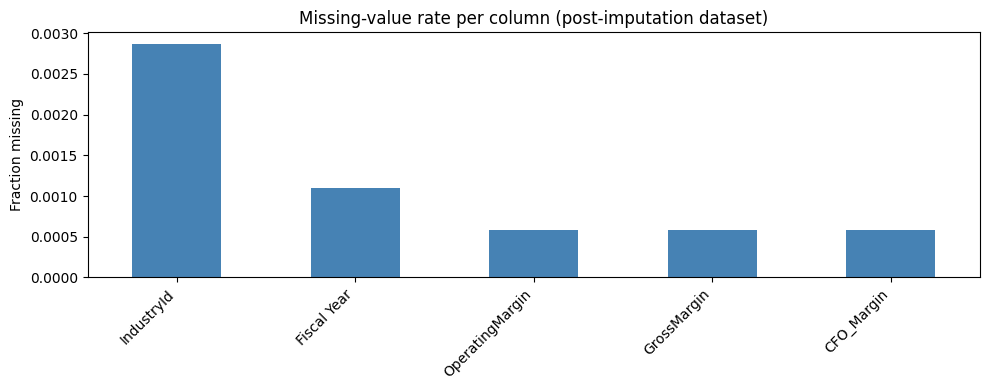

In [5]:
# ── Missing values overview ──────────────────────────────────────────────────
num_cols = df.select_dtypes(include='number').columns.tolist()
miss = df[num_cols].isnull().mean().sort_values(ascending=False)
miss = miss[miss > 0]

print(f"Columns with any missing values: {len(miss)}")
print("\nMissing-rate table:")
print(miss.to_frame('missing_rate').round(4))

# Bar chart
if len(miss) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ['red' if v > 0.5 else 'orange' if v > 0.1 else 'steelblue' for v in miss.values]
    miss.plot(kind='bar', color=colors, ax=ax)
    ax.set_title('Missing-value rate per column (post-imputation dataset)')
    ax.set_ylabel('Fraction missing')
    ax.set_xlabel('')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values remain in numeric columns.")

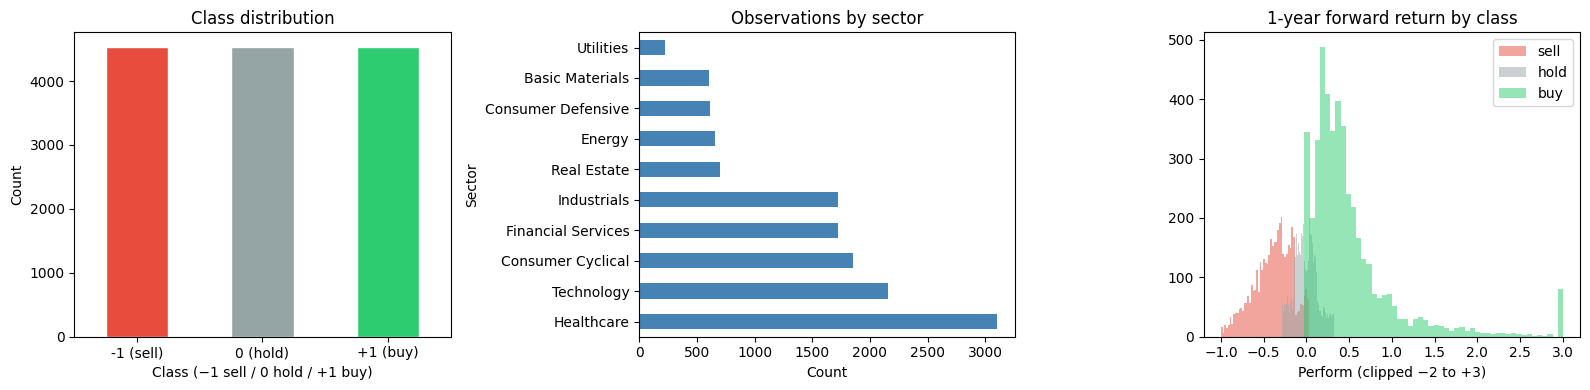

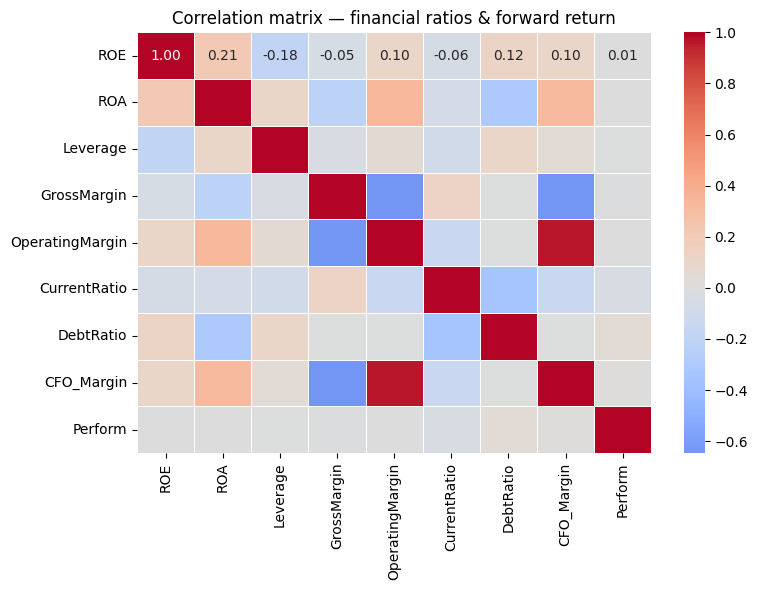

In [6]:
# ── EDA: Class distribution, Sector breakdown, Ratio correlations ────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Class distribution
class_counts = df['Class'].value_counts().sort_index()
class_counts.plot(kind='bar', ax=axes[0], color=['#e74c3c','#95a5a6','#2ecc71'],
                  edgecolor='white')
axes[0].set_title('Class distribution')
axes[0].set_xlabel('Class (−1 sell / 0 hold / +1 buy)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['-1 (sell)', '0 (hold)', '+1 (buy)'], rotation=0)

# 2. Sector breakdown
sector_counts = df['Sector'].value_counts().head(10)
sector_counts.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Observations by sector')
axes[1].set_xlabel('Count')

# 3. Forward return distribution by class
for cls, color, label in [(-1,'#e74c3c','sell'), (0,'#95a5a6','hold'), (1,'#2ecc71','buy')]:
    axes[2].hist(df.loc[df['Class']==cls, 'Perform'].clip(-2, 3),
                 bins=50, alpha=0.5, color=color, label=label)
axes[2].set_title('1-year forward return by class')
axes[2].set_xlabel('Perform (clipped −2 to +3)')
axes[2].legend()

plt.tight_layout()
plt.show()

# Correlation heatmap for derived ratios
fig2, ax2 = plt.subplots(figsize=(8, 6))
corr = df[RATIO_COLS + ['Perform']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax2,
            linewidths=0.5)
ax2.set_title('Correlation matrix — financial ratios & forward return')
plt.tight_layout()
plt.show()

## 4. Planned Methods

The mission applies at least one technique from each of the three mandatory blocks. Ticked items below are the methods we plan to use; each choice is justified in terms of the research question and dataset properties.


### 4a. Causal Inference

- [x] **Causal graph / DAG (DoWhy)**
- [x] **Backdoor adjustment**
- [ ] Instrumental variable
- [ ] Propensity score stratification

*Justification:*  
We ask whether high return-on-equity (ROE) *causally* increases the probability of a buy signal after controlling for sector and leverage. A DAG is the minimal formal structure required to state that assumption precisely and to identify a valid adjustment set. The backdoor criterion applies because Sector and Leverage are observed confounders on the path ROE → Class, so conditioning on them blocks all non-causal paths without introducing collider bias.

**DAG structure (structural assumptions):**

```
Sector ──→ Leverage
Sector ──→ Buy
Leverage ──→ ROE_high
ROE_high ──→ Buy          ← path of interest (ATE)
```

- *Sector → Leverage*: capital structure norms differ by industry (financials and utilities carry high leverage by design).
- *Sector → Buy*: sector-level tailwinds create return differentials independent of firm-level fundamentals.
- *Leverage → ROE_high*: leverage amplifies ROE mechanically via the DuPont identity (ROE = ROA × Equity Multiplier).
- *ROE_high → Buy*: our causal hypothesis — higher profitability relative to sector peers increases the probability of being a top-tercile return stock.

**Identification:** backdoor adjustment on {Sector, Leverage} satisfies the backdoor criterion for the treatment ROE_high and outcome Buy.  
**Validation:** ≥ 2 DoWhy refutation tests — `add_unobserved_common_cause` and `placebo_treatment_refuter`.

**Synthesis with other blocks:** If the RF/CatBoost feature importances (Section 4b) rank ROE and Leverage as top predictors, this is consistent with the causal DAG. If the causal ATE is small but the supervised model exploits these features heavily, it signals that the predictive signal is largely correlational rather than structural — which we discuss explicitly in Section 8.


### 4b. Supervised Learning

- [ ] Linear / Ridge / Lasso regression
- [x] **Logistic regression** (Softmax / multinomial, used in the Soft Voting Ensemble)
- [ ] k-Nearest Neighbors
- [ ] Support Vector Machine
- [x] **Decision Tree / Random Forest** (primary interpretable model; feature importances)
- [ ] Neural network
- [x] **Other:** CatBoost (gradient boosting), HistGradientBoosting, Soft Voting Ensemble (RF + CatBoost + Softmax)

*Justification:*  
The task is ternary classification (sell / hold / buy) on structured tabular data with mixed ratio and categorical features. Ensemble tree models (RF, CatBoost) are the established best practice for this data type: they handle non-linear interactions, are robust to outlier ratios, and require no feature scaling. Softmax regression provides a linear baseline within the ensemble and ensures diversity — its errors are structurally different from tree models, making soft voting genuinely useful. HistGradientBoosting is included as a second gradient-boosting reference.

**Feature set:** 8 derived financial ratios + 5 year-over-year ratio changes + log(Total Assets) + Sector dummies + Cluster membership from Section 4c.

**Temporal split:** train on FY2021–2022 (excluding COVID-anomalous 2020), validate on FY2023. No look-ahead bias.

**Fama-French 3-factor economic baseline:**  
We download monthly FF3 factors (Market, SMB, HML) from the Kenneth French Data Library via `pandas-datareader` and fit a time-series factor regression for each firm using trailing 12-month returns. The factor model's predicted excess return is converted to a directional class label (top tercile → buy, bottom → sell) using the same within-year tercile rule as our target. This baseline tests whether our ML model adds genuine economic value beyond established factor heuristics, or merely re-packages known market risks. We report FF3 macro F1 alongside all ML models in the summary table.

**Synthesis with unsupervised block:** Cluster membership from Section 4c is a feature in the supervised model. An ablation study (with vs. without Cluster) quantifies how much of the supervised performance gain comes from the latent fundamental profiles discovered by PCA + K-Means.


### 4c. Unsupervised / Generative Learning

- [x] **K-Means clustering** (segment firms into latent fundamental archetypes)
- [x] **Hierarchical clustering** (Ward linkage; dendrogram to validate k independently of K-Means)
- [ ] Variational autoencoder
- [ ] GAN
- [x] **Other:** PCA (dimensionality reduction before clustering)

*Justification:*  
The 8 financial ratios are strongly collinear (ROE and ROA both capture profitability; Leverage and DebtRatio both capture solvency). PCA decorrelates them and projects firms into a low-dimensional fundamental space where K-Means distance metrics are more stable and interpretable. Hierarchical clustering (Ward) cross-validates the number of natural clusters via dendrogram without requiring a pre-specified k. We select the final k using both the elbow criterion on inertia and the silhouette score.

**Synthesis with supervised block:** The cluster label is added as a categorical feature to the supervised classifier (Section 4b). An ablation study measures the marginal information contribution of cluster membership. Cluster profiles (mean ratio values, sector composition, median Perform) are mapped to Fama-French style/value categories to provide economic interpretation.

**Synthesis with causal block:** If high-ROE firms cluster into a distinct 'quality' archetype (Cluster 0 in our preliminary results), the causal ATE of ROE on Buy should be largest within that cluster — providing a consistency check on the DAG structural assumptions.


## 5. Evaluation Strategy

**Supervised learning metrics:**  
Per-class precision, recall, and F1-score (macro-averaged) as the primary statistical metric. Directional accuracy (fraction of correct buy/sell direction calls) as the primary economic metric. AUC-OVR (one-vs-rest) to evaluate probability calibration. All reported on the temporal hold-out set (FY2023).

**Economic baselines:**
- *Majority-class baseline:* always predict the most frequent class — sanity check for class imbalance.
- *Random baseline:* uniform random prediction — lower bound.
- *Fama-French 3-factor baseline:* predicted excess return direction from a time-series factor regression on Market, SMB, HML. Tests whether the ML model adds economic value beyond standard factor heuristics. Whether or not ML outperforms FF3, we explain *why* it behaves as it does from an economic perspective.

**Causal validation:**  
At least two DoWhy refutation tests: `add_unobserved_common_cause` (sensitivity to hidden confounders) and `placebo_treatment_refuter` (should yield near-zero ATE). We interpret whether the ROE → Buy causal effect survives both tests and discuss what this implies about the structural vs. correlational nature of the profitability–return relationship.

**Unsupervised evaluation:**  
Silhouette score across k = 2–8; elbow criterion on inertia; economic profiling of clusters against FF value/growth/quality style proxies; ablation study comparing supervised model performance with vs. without Cluster features.

**Survivorship bias robustness:**  
The SimFin free tier covers only currently-listed US firms; bankrupt or delisted firms are absent, biasing fundamentals toward survivorship. We assess the severity by checking whether class distributions and median fundamentals shift across fiscal years (a stable bias would produce consistent class balance, which our within-year tercile construction guarantees by design). We flag this as a key limitation in Section 8 and discuss the direction of the expected bias.

**Synthesis criterion:**  
The mission succeeds if each block informs the next: (1) PCA/K-Means cluster profiles → feature engineering and economic interpretation for the supervised block; (2) supervised feature importances → consistency check on the causal DAG (are the structural variables also the predictive ones?); (3) causal ATE vs. supervised performance → distinguishes genuine economic drivers from correlates; (4) ML vs. FF3 directional accuracy → quantifies economic value-add. Whether or not ML outperforms FF3 is less important than our ability to explain the result from an economic perspective.


## 6. Work Plan

| # | Task | Owner | Deliverable |
|---|------|-------|-------------|
| 1 | Data retrieval & pipeline — load SimFin income, balance, cash-flow, prices; merge; compute forward returns; assign Class labels | Mariia | `simfin_data_retrieval.ipynb`, `simfin_dataset.csv` |
| 2 | Data cleaning & imputation — drop high-missing columns, sector-median imputation, save cleaned dataset | Lutz | `missing_values_analysis.ipynb`, `simfin_cleaned_imputed.csv` |
| 3 | EDA & ratio derivation — derive 8 financial ratios, winsorise, produce class/sector/return distribution plots and correlation heatmap | Mariia | Executed cells in proposal (Section 3) |
| 4 | Unsupervised block — z-score scaling, PCA (≥80% variance), k-means (elbow + silhouette), Ward hierarchical clustering, cluster profiling | Mariia | Section 7c |
| 5 | Causal inference block — binarise ROE treatment, build DoWhy CausalModel with DAG, estimate ATE via backdoor, run ≥ 2 refutation tests | Lutz | Section 7a |
| 6 | Supervised learning block — temporal train/val/test split, Random Forest + XGBoost + CatBoost, cost-sensitive rules, SHAP feature importance | Mariia | Section 7b |
| 7 | Fama-French baseline — download FF3 factors (Kenneth French library), fit factor model, convert to directional Class labels, compare vs. ML | Lutz | Section 7b (baseline comparison) |
| 8 | Synthesis & Discussion — connect cluster profiles → causal interpretation → supervised performance; limitations (survivorship bias, ratio choices); conclusion | Mariia + Lutz | Section 8 |